In [2]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
warnings.filterwarnings('ignore')

In [3]:
pd.set_option('display.max_columns', None)

In [4]:
plt.rcParams.update({
    'figure.figsize'   : (14, 5),
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.titlesize'   : 13,
    'axes.labelsize'   : 11,
})
sns.set_palette("muted")

print("Libraries loaded")

Libraries loaded


In [5]:
df = pd.read_csv('../Data/Cleaned/mta_ridership_cleaned.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)

In [6]:
print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Date range: {df['date'].min().strftime('%d %b %Y')} -> {df['date'].max().strftime('%d %b %Y')}")
print(f"Nulls: {df.isnull().sum().sum()}")

Loaded: 1,776 rows x 21 columns
Date range: 01 Mar 2020 -> 09 Jan 2025
Nulls: 0


In [7]:
TARGET = 'subway_ridership'

RIDERSHIP_COLS = [
    'subway_ridership', 'bus_ridership', 'lirr_ridership',
    'metro_north_ridership', 'access_ride_trips',
    'bridges_tunnels_traffic', 'staten_island_ridership'
]

BASELINE_COLS = [
    'subway_pct_baseline', 'bus_pct_baseline', 'lirr_pct_baseline',
    'metro_north_pct_baseline', 'access_ride_pct_baseline',
    'bridges_tunnels_pct_baseline', 'staten_island_pct_baseline'
]

FLAG_COLS = ['is_covid', 'is_weekend', 'is_holiday', 'is_outlier']

print(f"Variables defined")
print(f"TARGET        : {TARGET}")
print(f"Ridership cols: {len(RIDERSHIP_COLS)}")
print(f"Baseline cols : {len(BASELINE_COLS)}")
print(f"Flag cols     : {len(FLAG_COLS)}")

Variables defined
TARGET        : subway_ridership
Ridership cols: 7
Baseline cols : 7
Flag cols     : 4


In [8]:
print ('Univariate Analysis')
print (f'Column: {TARGET}')
print (f'Count: {df[TARGET].count():>12,}')
print (f'Mean : {df[TARGET].mean():>12,.0f}')
print (f'Median: {df[TARGET].median():>12,.0f}')
print(f"Std Dev: {df[TARGET].std():>12,.0f}")
print(f"Min    : {df[TARGET].min():>12,.0f}")
print(f"Max    : {df[TARGET].max():>12,.0f}")
print(f"Skew   : {df[TARGET].skew():>12.4f}")
print(f"Kurt   : {df[TARGET].kurtosis():>12.4f}")
print(f"CV     : {df[TARGET].std()/df[TARGET].mean()*100:>11.2f}%") 

Univariate Analysis
Column: subway_ridership
Count:        1,776
Mean :    2,541,830
Median:    2,505,354
Std Dev:    1,067,641
Min    :      198,399
Max    :    5,498,809
Skew   :      -0.1656
Kurt   :      -0.9273
CV     :       42.00%


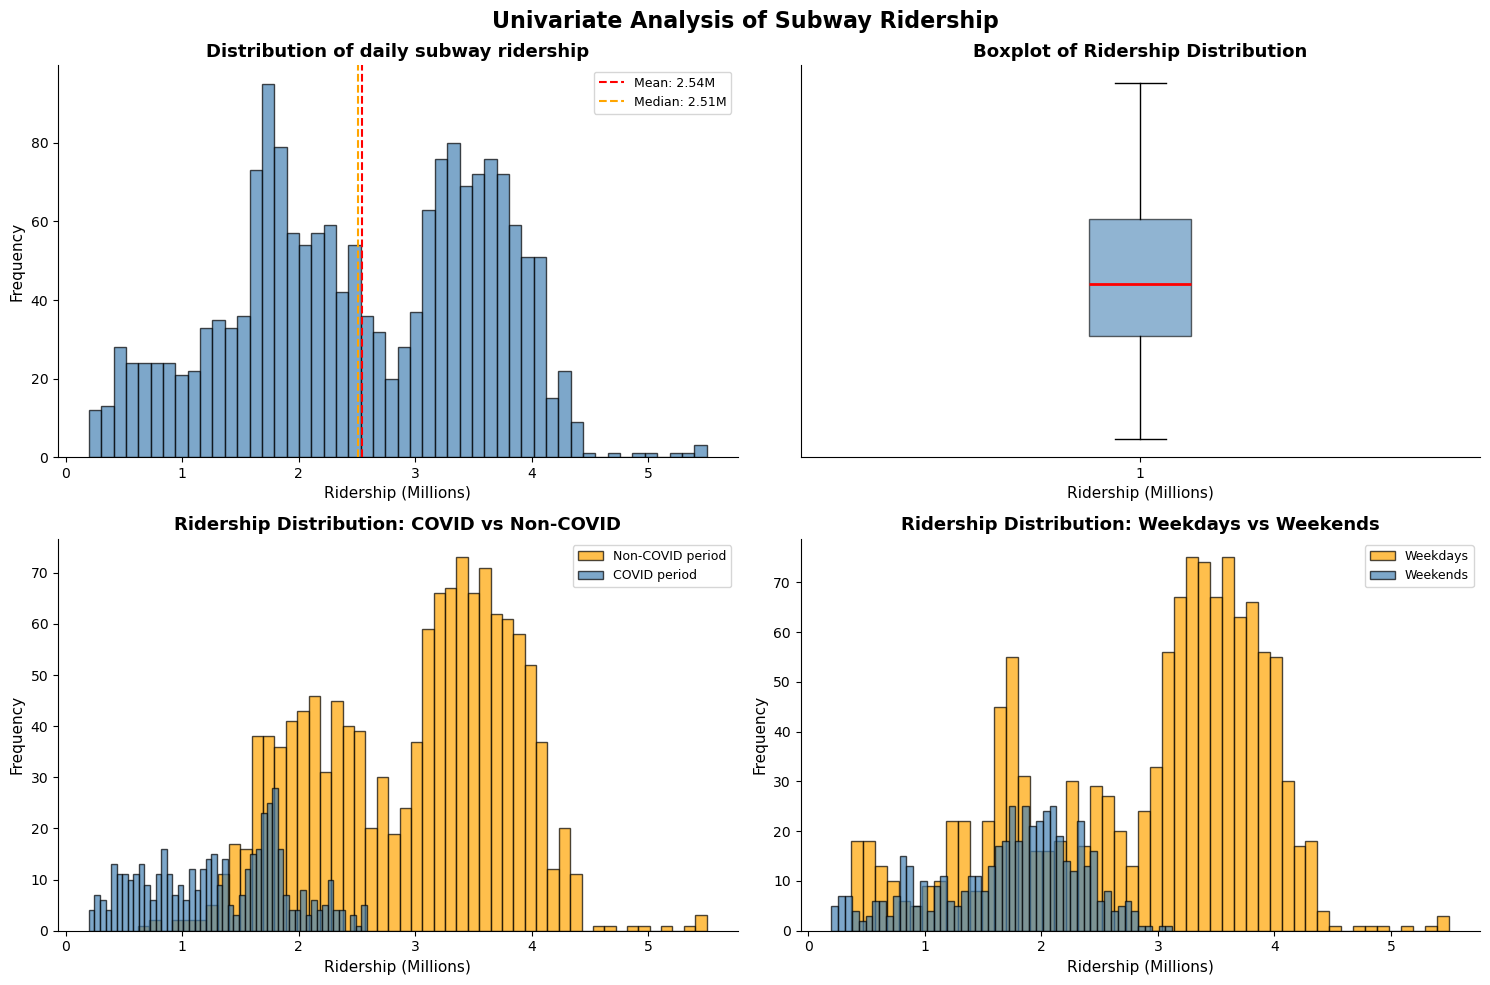

Saved to Reports


<Figure size 1400x500 with 0 Axes>

In [9]:
fig,axes = plt.subplots(2, 2, figsize=(15, 10))

#histogram for daily subway ridership
axes [0,0].hist(df[TARGET]/1e6, bins=50, color='steelblue', edgecolor='black', alpha = 0.7)
axes[0,0].axvline(df[TARGET].mean()/1e6, color='red',
                  linestyle='--', linewidth=1.5,
                  label=f"Mean: {df[TARGET].mean()/1e6:.2f}M")
axes[0,0].axvline(df[TARGET].median()/1e6, color='orange',
                  linestyle='--', linewidth=1.5,
                  label=f"Median: {df[TARGET].median()/1e6:.2f}M")
axes[0,0].set_title(f"Distribution of daily subway ridership", fontweight='bold') 
axes[0,0].set_xlabel("Ridership (Millions)")
axes[0,0].set_ylabel("Frequency")
axes[0,0].legend(fontsize=9)

#boxplot for ridership distribution
axes[0,1].boxplot(df[TARGET]/1e6, vert=True, patch_artist=True,
                  boxprops=dict(facecolor='steelblue', alpha=0.6),
                  medianprops=dict(color='red', linewidth=2),
                  flierprops=dict(marker='o', markerfacecolor='red',
                                  markersize=4, alpha=0.5))
axes[0,1].set_title(f"Boxplot of Ridership Distribution", fontweight='bold')
axes[0,1].set_xlabel("Ridership (Millions)")
axes[0,1].set_yticks([])

#ridership distribution: COVID vs Non-COVID
axes[1,0].hist(df[df['is_covid']==0][TARGET]/1e6, bins=50, color='orange', edgecolor='black', label = 'Non-COVID period', alpha = 0.7)
axes[1,0].hist(df[df['is_covid']==1][TARGET]/1e6, bins=50, color='steelblue', edgecolor='black', label = 'COVID period', alpha = 0.7)
axes[1,0].set_title(f"Ridership Distribution: COVID vs Non-COVID", fontweight='bold')
axes[1,0].set_xlabel("Ridership (Millions)")
axes[1,0].set_ylabel("Frequency")
axes[1,0].legend(fontsize=9)

axes[1,1].hist(df[df['is_weekend']==0][TARGET]/1e6, bins=50, color='orange', edgecolor='black', label = 'Weekdays', alpha = 0.7)
axes[1,1].hist(df[df['is_weekend']==1][TARGET]/1e6, bins=50, color='steelblue', edgecolor='black', label = 'Weekends', alpha = 0.7)
axes[1,1].set_title(f"Ridership Distribution: Weekdays vs Weekends", fontweight='bold')
axes[1,1].set_xlabel("Ridership (Millions)")
axes[1,1].set_ylabel("Frequency")
axes[1,1].legend(fontsize=9)

plt.suptitle ('Univariate Analysis of Subway Ridership', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
plt.savefig('../Reports/03_univariate_analysis.png', dpi=150, bbox_inches='tight')
print("Saved to Reports")

In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [11]:
ts = df.set_index('date')[TARGET]
decomposition = seasonal_decompose(ts, model = 'additive', period = 7)

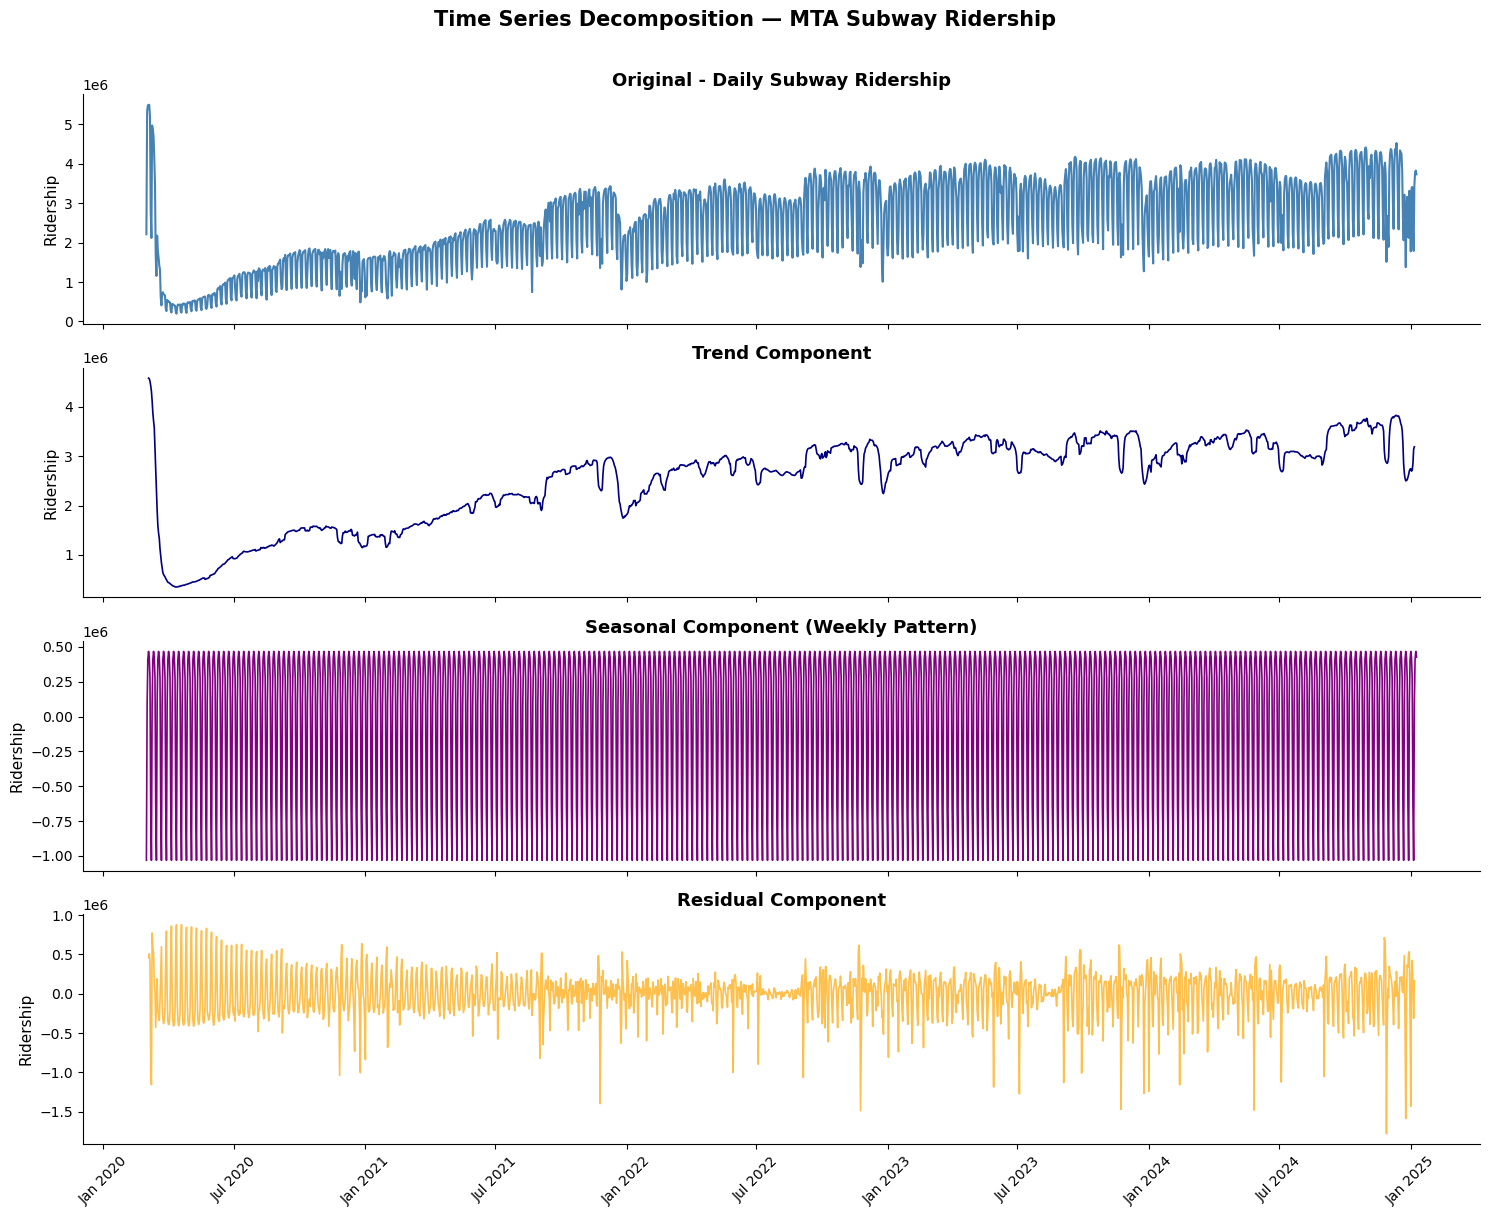

Saved to Reports


In [12]:
fig,axes = plt.subplots (4, 1, figsize=(15, 12), sharex=True)

axes[0].plot(ts, color='steelblue', label='Original')
axes[0].set_title('Original - Daily Subway Ridership', fontweight='bold')
axes[0].set_ylabel('Ridership')

axes [1].plot(decomposition.trend, color='navy', linewidth = 1.2)
axes[1].set_title('Trend Component', fontweight='bold')
axes[1].set_ylabel('Ridership')

axes [2].plot(decomposition.seasonal, color='purple', linewidth = 1.2)
axes[2].set_title('Seasonal Component (Weekly Pattern)', fontweight='bold')
axes[2].set_ylabel('Ridership')

axes [3].plot(decomposition.resid, color='orange', linewidth = 1.2, alpha = 0.7)
axes[3].set_title('Residual Component', fontweight='bold')
axes[3].set_ylabel('Ridership')

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.suptitle("Time Series Decomposition — MTA Subway Ridership",
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../Reports/03_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to Reports")

In [13]:
#weekly seasonality analysis
day_order  = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

avg_by_day = df.groupby('day_name')[TARGET].mean().reindex(day_order)
med_by_day = df.groupby('day_name')[TARGET].median().reindex(day_order)

print ('Average Ridership by Day of the Week:')
for day, val in avg_by_day.items():
    bar = '█' * int(val/1e6/0.5)  # 1 bar per 0.5 million ridership
    print (f'{day:<12}: {val:>10,.0f} {bar}')

Average Ridership by Day of the Week:
Monday      :  2,631,651 █████
Tuesday     :  2,955,051 █████
Wednesday   :  3,009,866 ██████
Thursday    :  2,968,433 █████
Friday      :  2,814,682 █████
Saturday    :  1,903,372 ███
Sunday      :  1,508,318 ███


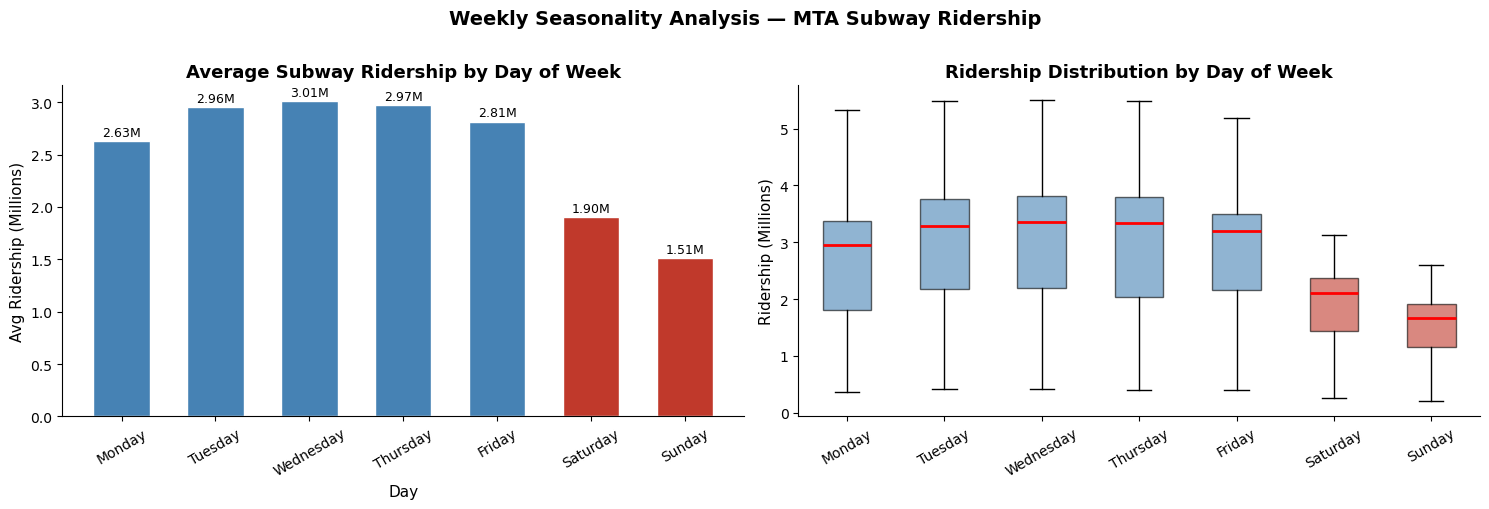

 Saved to Reports


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

#bar chart of the day of the week
colors = ['#c0392b' if d in ['Saturday','Sunday'] else 'steelblue' for d in day_order]
bars = axes[0].bar(day_order, avg_by_day/1e6, color=colors, edgecolor='white', width=0.6)
axes[0].set_title("Average Subway Ridership by Day of Week", fontweight='bold')
axes[0].set_ylabel("Avg Ridership (Millions)")
axes[0].set_xlabel("Day")
for bar, val in zip(bars, avg_by_day/1e6):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.02,
                 f'{val:.2f}M', ha='center', va='bottom', fontsize=9)
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30)

#boxplot by day of week

day_data = [df[df['day_name']==day][TARGET]/1e6 for day in day_order]
bp = axes[1].boxplot(day_data, labels=day_order, patch_artist=True,
                     medianprops=dict(color='red', linewidth=2))
for patch, day in zip(bp['boxes'], day_order):
    patch.set_facecolor('#c0392b' if day in ['Saturday','Sunday'] else 'steelblue')
    patch.set_alpha(0.6)
axes[1].set_title("Ridership Distribution by Day of Week", fontweight='bold')
axes[1].set_ylabel("Ridership (Millions)")
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30)

plt.suptitle("Weekly Seasonality Analysis — MTA Subway Ridership",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../Reports/03_weekly_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved to Reports")

In [15]:
df['month'] = df['date'].dt.month
df['year']  = df['date'].dt.year
df['month_name'] = df['date'].dt.strftime('%b')

month_order = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

avg_by_month = df.groupby('month_name')[TARGET].mean().reindex(month_order)

print("AVERAGE RIDERSHIP BY MONTH")

for month, val in avg_by_month.items():
    print(f"  {month:<5}: {val:>12,.0f}")


AVERAGE RIDERSHIP BY MONTH
  Jan  :    2,353,428
  Feb  :    2,512,832
  Mar  :    2,661,711
  Apr  :    2,282,775
  May  :    2,398,359
  Jun  :    2,477,126
  Jul  :    2,353,224
  Aug  :    2,392,631
  Sep  :    2,710,013
  Oct  :    2,865,303
  Nov  :    2,786,123
  Dec  :    2,676,702


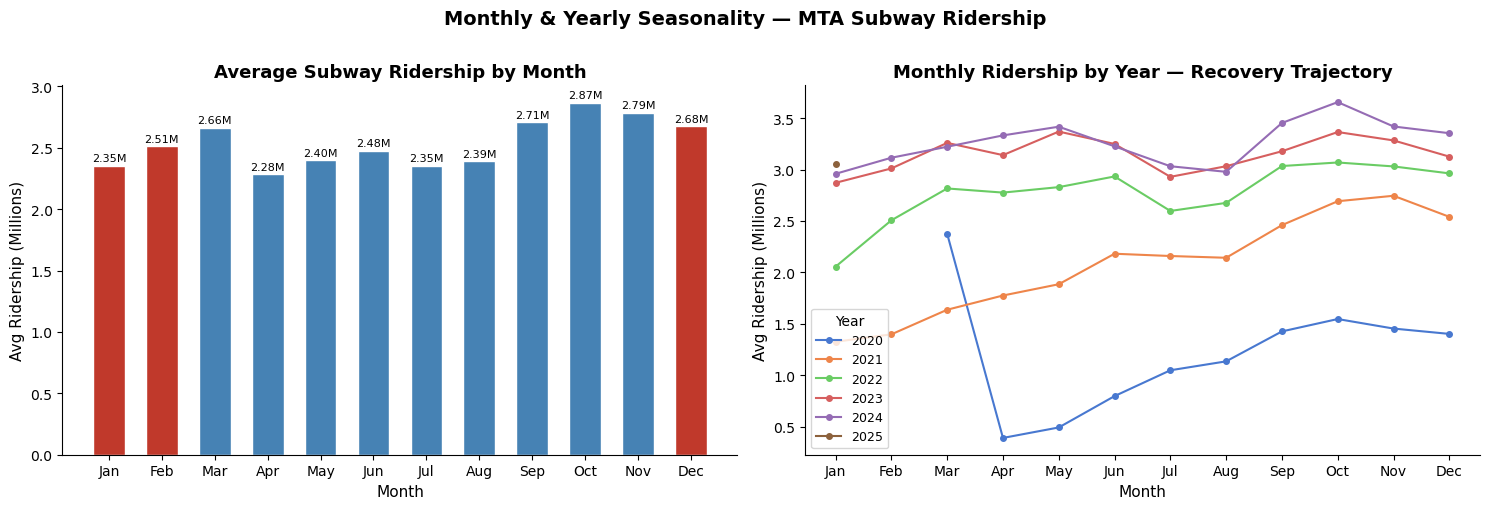

Saved to Reports|


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

#Average ridership by month bar chart
colors = ['#c0392b' if m in ['Jan','Feb','Dec'] else 'steelblue' for m in month_order]
bars = axes[0].bar(month_order, avg_by_month/1e6, color=colors, edgecolor='white', width=0.6)
axes[0].set_title("Average Subway Ridership by Month", fontweight='bold')
axes[0].set_ylabel("Avg Ridership (Millions)")
axes[0].set_xlabel("Month")
for bar, val in zip(bars, avg_by_month/1e6):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.02,
                 f'{val:.2f}M', ha='center', va='bottom', fontsize=8)

#Year over year line chart

for year in sorted(df['year'].unique()):
    year_data = df[df['year']==year].groupby('month')[TARGET].mean()
    axes[1].plot(year_data.index, year_data/1e6,
                 marker='o', markersize=4, linewidth=1.5, label=str(year))
axes[1].set_title("Monthly Ridership by Year — Recovery Trajectory", fontweight='bold')
axes[1].set_ylabel("Avg Ridership (Millions)")
axes[1].set_xlabel("Month")
axes[1].set_xticks(range(1,13))
axes[1].set_xticklabels(month_order)
axes[1].legend(title='Year', fontsize=9)\

plt.suptitle("Monthly & Yearly Seasonality — MTA Subway Ridership",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../Reports/03_monthly_yearly.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to Reports|")


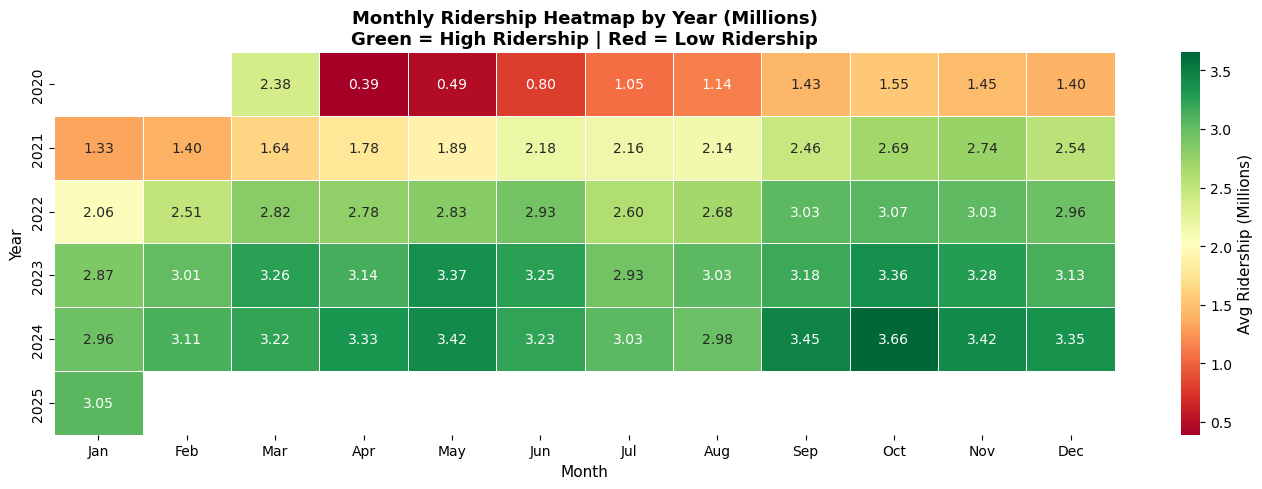

Saved to Reports


In [17]:
#Heatmap - Month vs Year 

pivot = df.groupby(['year','month_name'])[TARGET].mean().unstack()
pivot = pivot.reindex(columns=month_order)
pivot = pivot / 1e6  # convert to millions

plt.figure(figsize=(14, 5))
sns.heatmap(
    pivot,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    linewidths=0.5,
    cbar_kws={'label': 'Avg Ridership (Millions)'}
)
plt.title("Monthly Ridership Heatmap by Year (Millions)\nGreen = High Ridership | Red = Low Ridership",
          fontweight='bold', fontsize=13)
plt.xlabel("Month")
plt.ylabel("Year")
plt.tight_layout()
plt.savefig('../Reports/03_monthly_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to Reports")

In [18]:
pre_covid = df[df['date'] < '2020-03-22']
during_covid = df[(df['date'] >= '2020-03-22') & (df['date'] <= '2021-07-01')]
post_covid = df[df['date'] > '2021-07-01']

In [21]:
print ('Covid Impact Analysis')
print (f'\n Pre - Covid (before Mar 22, 2020)')
print (f'Days: {len(pre_covid):,}')
print (f'Avg Daily: {pre_covid[TARGET].mean():>12,.0f}')
print (f'Max Daily: {pre_covid[TARGET].max():>12,.0f}')

print (f'\n During Covid (Mar 22, 2020 - Jul 1, 2021)')
print (f'Days: {len (during_covid):,}')
print (f'Avg Daily: {during_covid[TARGET].mean():>12,.0f}')
print (f'Max Daily: {during_covid[TARGET].max():>12,.0f}')

print (f'\n Post Covid (After Jul1, 2021)')
print (f'Daily: {len(post_covid):,}')
print (f'Avg Daily: {post_covid[TARGET].mean():>12,.0f}')
print (f'Max Daily:  {post_covid[TARGET].max():>,.0f}')

Covid Impact Analysis

 Pre - Covid (before Mar 22, 2020)
Days: 21
Avg Daily:    3,242,323
Max Daily:    5,498,809

 During Covid (Mar 22, 2020 - Jul 1, 2021)
Days: 467
Avg Daily:    1,311,427
Max Daily:    2,582,713

 Post Covid (After Jul1, 2021)
Daily: 1,288
Avg Daily:    2,976,526
Max Daily:  4,527,892


In [22]:
drop_pct = (during_covid[TARGET].mean() - pre_covid[TARGET].mean()) / pre_covid[TARGET].mean() * 100
recovery_pct = (post_covid[TARGET].mean() - pre_covid[TARGET].mean()) / pre_covid[TARGET].mean() * 100

In [24]:
print(f"\n Key Metrics")
print(f"Ridership drop during COVID : {drop_pct:>+.1f}%")
print(f"Post-COVID vs Pre-COVID     : {recovery_pct:>+.1f}%")


 Key Metrics
Ridership drop during COVID : -59.6%
Post-COVID vs Pre-COVID     : -8.2%


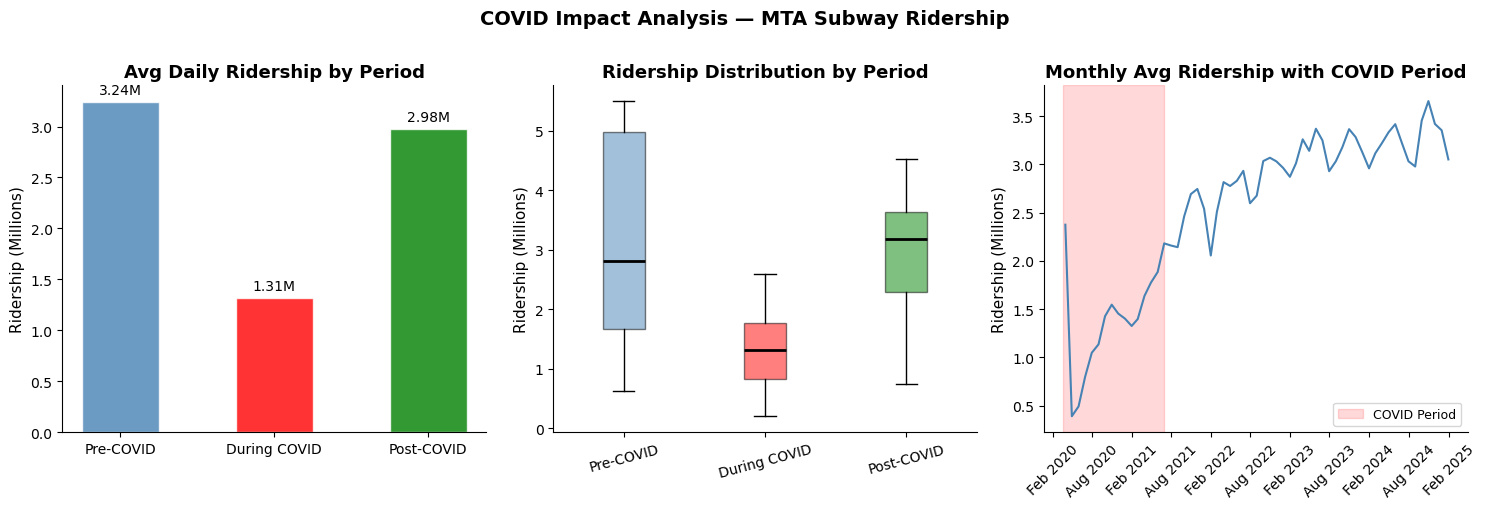

Saved to Reports


In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

#chart 1 - bar chart

periods     = ['Pre-COVID', 'During COVID', 'Post-COVID']
period_avgs = [pre_covid[TARGET].mean()/1e6,
               during_covid[TARGET].mean()/1e6,
               post_covid[TARGET].mean()/1e6]
colors = ['steelblue', 'red', 'green']

bars = axes[0].bar(periods, period_avgs, color=colors,
                   edgecolor='white', alpha=0.8, width=0.5)
axes[0].set_title("Avg Daily Ridership by Period", fontweight='bold')
axes[0].set_ylabel("Ridership (Millions)")

for bar, val in zip(bars, period_avgs):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.05,
                 f'{val:.2f}M', ha='center', va='bottom', fontsize=10)
    

#chart 2 - box plot

box_data   = [pre_covid[TARGET]/1e6,
              during_covid[TARGET]/1e6,
              post_covid[TARGET]/1e6]
bp = axes[1].boxplot(box_data, labels=periods, patch_artist=True,
                     medianprops=dict(color='black', linewidth=2))

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.5)
axes[1].set_title("Ridership Distribution by Period", fontweight='bold')
axes[1].set_ylabel("Ridership (Millions)")
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=15)

#chart 3 - monthly avg with period shading

monthly_avg = df.groupby('date')[TARGET].mean().reset_index()
monthly_avg = monthly_avg.set_index('date').resample('M').mean()

axes[2].plot(monthly_avg.index, monthly_avg[TARGET]/1e6,
             color='steelblue', linewidth=1.5)
axes[2].axvspan(pd.Timestamp('2020-03-22'), pd.Timestamp('2021-07-01'),
                alpha=0.15, color='red', label='COVID Period')
axes[2].set_title("Monthly Avg Ridership with COVID Period", fontweight='bold')
axes[2].set_ylabel("Ridership (Millions)")
axes[2].legend(fontsize=9)
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[2].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=45)


plt.suptitle ("COVID Impact Analysis — MTA Subway Ridership",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../Reports/03_covid_impact.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to Reports")

In [27]:
short_names = {
    'subway_ridership'       : 'Subways',
    'bus_ridership'          : 'Buses',
    'lirr_ridership'         : 'LIRR',
    'metro_north_ridership'  : 'Metro-North',
    'access_ride_trips'      : 'Access-A-Ride',
    'bridges_tunnels_traffic': 'Bridges+Tunnels',
    'staten_island_ridership': 'Staten Island'
}

corr_df = df[RIDERSHIP_COLS].copy()
corr_df.columns = list(short_names.values())
corr_matrix = corr_df.corr()

print("Cross Modal Correlation Matrix")
print(corr_matrix.round(3).to_string())

print()
print("Subway Correlation with other modes:")
subway_corr = corr_matrix['Subways'].drop('Subways').sort_values(ascending=False)
for mode, val in subway_corr.items():
    direction = "positive" if val > 0 else "negative"
    strength  = "strong" if abs(val) > 0.8 else "moderate" if abs(val) > 0.5 else "weak"
    print(f"  {mode:<20}: {val:>+.4f}  ({strength} {direction})")

Cross Modal Correlation Matrix
                 Subways  Buses   LIRR  Metro-North  Access-A-Ride  Bridges+Tunnels  Staten Island
Subways            1.000  0.884  0.961        0.943          0.909            0.738          0.923
Buses              0.884  1.000  0.794        0.746          0.782            0.693          0.859
LIRR               0.961  0.794  1.000        0.971          0.935            0.701          0.894
Metro-North        0.943  0.746  0.971        1.000          0.882            0.657          0.844
Access-A-Ride      0.909  0.782  0.935        0.882          1.000            0.687          0.866
Bridges+Tunnels    0.738  0.693  0.701        0.657          0.687            1.000          0.569
Staten Island      0.923  0.859  0.894        0.844          0.866            0.569          1.000

Subway Correlation with other modes:
  LIRR                : +0.9611  (strong positive)
  Metro-North         : +0.9426  (strong positive)
  Staten Island       : +0.9233  (str

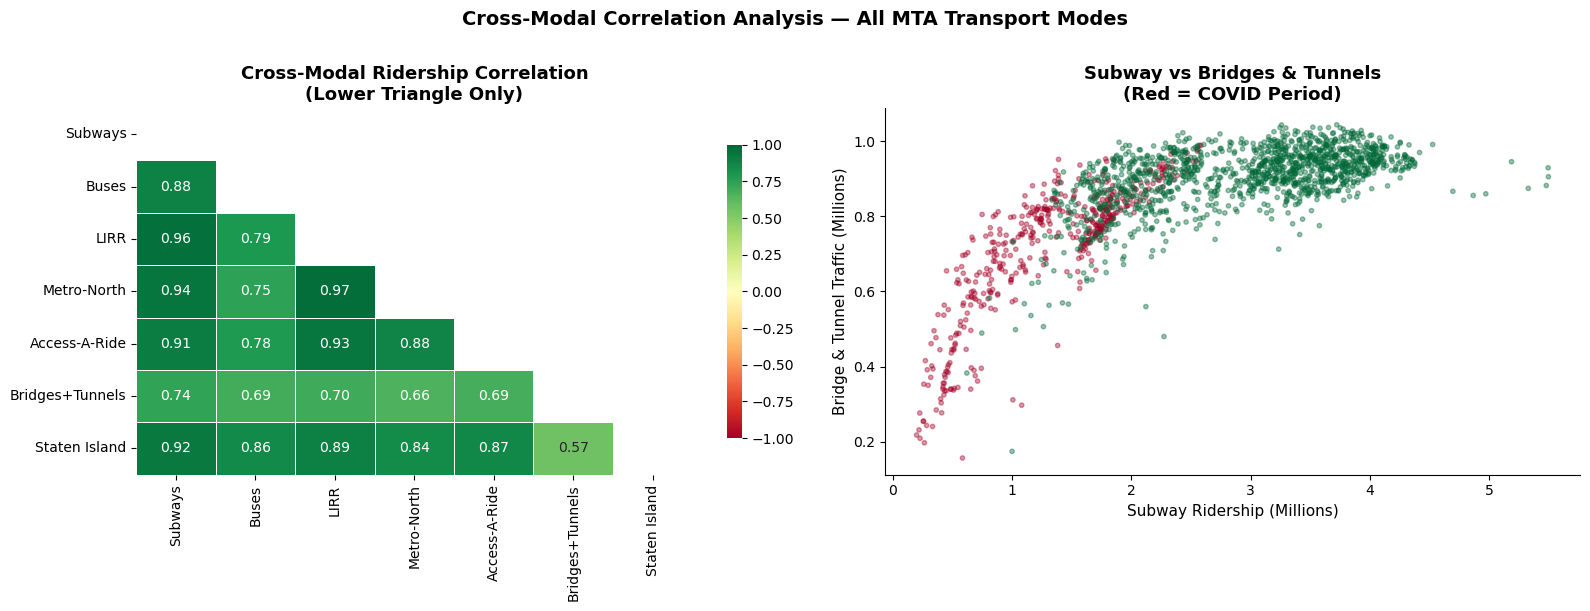

Saved to Reports


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))


#chart 1 - correlation heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=axes[0],
    cbar_kws={'shrink': 0.8}
)

axes[0].set_title("Cross-Modal Ridership Correlation\n(Lower Triangle Only)",
                  fontweight='bold')

#chart 2 - scatter — subway vs bridges & tunnels

axes[1].scatter(
    df['subway_ridership']/1e6,
    df['bridges_tunnels_traffic']/1e6,
    c=df['is_covid'],
    cmap='RdYlGn_r',
    alpha=0.4, s=10
)

axes[1].set_title("Subway vs Bridges & Tunnels\n(Red = COVID Period)",
                  fontweight='bold')
axes[1].set_xlabel("Subway Ridership (Millions)")
axes[1].set_ylabel("Bridge & Tunnel Traffic (Millions)")

plt.suptitle("Cross-Modal Correlation Analysis — All MTA Transport Modes",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../Reports/03_cross_modal_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to Reports")